# Model Comparison

The goal of this notebook is to compare best-performing models developed throughout the project and select the final model for deployment.

Although several linear models were evaluated, even the best-performing linear model showed noticieably weaker results compared to tree-based models. Thefore, this final stage focuses on the two strongest models from the previous experiments:

* XGBoost
* CatBoost

The models will be compared based not only on their overall performance, but also on their generalization and prediction behaviour, with the final model selected based on the results of this analysis.

In [1]:
%load_ext autoreload
%autoreload 2


import pandas as pd
import numpy as np
import sys
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import catboost
import xgboost as xgb
import sklearn

pd.set_option("display.max_columns", 500)

sys.path.append(str(Path().cwd().parent.resolve()))

import preprocessing.features as features

builder = features.FeatureBuilder()

df = pd.read_csv(features.DATASET_PATH)

df.shape

/home/carl/notebooks/airbnb_prices_prediction/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(74111, 29)

# Load Final Models

## XGBoost

In [2]:
from optuna_integration import XGBoostPruningCallback
import optuna

def objective(trial, alpha=0.0):

    params = {
        "objective": "reg:squarederror",
        "eval_metric": "rmse",
        "tree_method": "hist",
        "device": DEVICE,
        
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.08, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "subsample": trial.suggest_float("subsample", 0.6, 0.9),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 0.8),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "min_child_weight": trial.suggest_int("min_child_weight", 5, 20),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 5, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1, 20, log=True),

        "verbosity": 0,
        "n_jobs": -1,
        "seed": 42
    }

    cv_results = xgb.cv(
        params=params,
        dtrain=dtrain,
        early_stopping_rounds=50,
        num_boost_round=1000,
        nfold=3,
        metrics="rmse",
        seed=42,
        verbose_eval=False,
        shuffle=True,
        callbacks=[XGBoostPruningCallback(trial, "test-rmse")]
    )

    trial.set_user_attr(
        "best_num_boost_round",
        len(cv_results)
    )

    test_rmse = cv_results['test-rmse-mean'].iloc[-1]
    train_rmse = cv_results['train-rmse-mean'].iloc[-1]

    gap = (test_rmse - train_rmse) / test_rmse
    
    trial.set_user_attr("gap", gap)
    trial.set_user_attr("train_rmse", train_rmse)
    trial.set_user_attr("test_rmse", test_rmse)

    score = test_rmse + alpha * gap

    return score

In [3]:
EMBEDDING_PCA_COMPONENTS = 370

df_copy = builder.get_df(df, use_amenities=True, use_embeddings=True, embedding_pca_components=EMBEDDING_PCA_COMPONENTS)

X = df_copy.drop(columns=['log_price'])
y = df_copy['log_price']

X.shape, y.shape

Loading embeddings from Parquet /home/carl/notebooks/airbnb_prices_prediction/dataset/description-embeddings.parquet...
Applying PCA (370 components)...
Embeddings shape is: (74111, 370)


((74111, 513), (74111,))

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    random_state=42,
    test_size=0.2
)

X_train.shape, X_test.shape

((59288, 513), (14823, 513))

In [5]:
from preprocessing import tree_preprocessor as preprocessor

cat_features = X_train.select_dtypes(include=['string', 'object']).columns

xgb_preprocessor = preprocessor.create_tree_preprocessor(cat_features)

X_train_processed = xgb_preprocessor.fit_transform(X_train, y_train)
X_test_processed = xgb_preprocessor.transform(X_test)

X_train_processed = X_train_processed.astype(np.float32)
X_test_processed = X_test_processed.astype(np.float32)

dtrain = xgb.DMatrix(X_train_processed, label=y_train)
dtest = xgb.DMatrix(X_test_processed, label=y_test)

In [6]:
XGBOOST_DIR = Path('../artifacts/xgboost')
XGBOOST_DIR.mkdir(exist_ok=True, parents=True)

XGBOOST_FULL_MODEL = XGBOOST_DIR / "xgboost_full_model"

In [7]:
%%time


from utils.xgb_pipeline import XGBoostPipeline

ALPHA = 0.03

if (
    XGBOOST_FULL_MODEL.with_suffix(".json").exists() and
    XGBOOST_FULL_MODEL.with_suffix(".joblib").exists() and
    XGBOOST_FULL_MODEL.with_suffix(".params").exists()
):
    print("Loading XGBoost full model...")
    xgboost_pipeline = XGBoostPipeline.load(XGBOOST_FULL_MODEL)
else:
    print("Training XGBoost full model...")
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    study = optuna.create_study(
        direction="minimize",
        pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=50, interval_steps=10)
    )

    study.optimize(
        lambda trial: objective(trial, alpha=ALPHA),
        n_trials=250,
        gc_after_trial=True
    )
    
    best_num_boost_round = study.best_trial.user_attrs['best_num_boost_round']
    
    best_params = {
        **study.best_params,
        "objective": "reg:squarederror",
        "eval_metric": "rmse",
        "tree_method": "hist",
        "n_jobs": -1,
        "seed": 42,
        "verbosity": 0,
        "device": DEVICE
    }

    xgboost_pipeline = XGBoostPipeline(preprocessor=tree_preprocessor)
    xgboost_pipeline.fit(
        X_train, y_train,
        params=best_params,
        num_boost_round=best_num_boost_round
    )

    xgboost_pipeline.save(XGBOOST_FULL_MODEL)

xgboost_pipeline.params

Loading XGBoost full model...
CPU times: user 131 ms, sys: 1.92 ms, total: 133 ms
Wall time: 47.6 ms


{'learning_rate': 0.04345080465833288,
 'max_depth': 5,
 'subsample': 0.8624856616170266,
 'colsample_bytree': 0.6228570487701548,
 'gamma': 0.0131076547373159,
 'min_child_weight': 5,
 'reg_alpha': 0.0808183197247493,
 'reg_lambda': 2.3439942334473773,
 'objective': 'reg:squarederror',
 'eval_metric': 'rmse',
 'tree_method': 'hist',
 'n_jobs': -1,
 'seed': 42,
 'verbosity': 0,
 'device': 'cuda'}

In [8]:
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

xgb_y_pred_test_log = xgboost_pipeline.predict(X_test)
y_pred_train_log = xgboost_pipeline.predict(X_train)

y_pred_test = np.exp(xgb_y_pred_test_log)
y_pred_train = np.exp(y_pred_train_log)

test_MAE = mean_absolute_error(np.exp(y_test), y_pred_test)
train_MAE = mean_absolute_error(np.exp(y_train), y_pred_train)

test_RMSE = root_mean_squared_error(np.exp(y_test), y_pred_test)
train_RMSE = root_mean_squared_error(np.exp(y_train), y_pred_train)

test_r2 = r2_score(y_test, xgb_y_pred_test_log)
train_r2 = r2_score(y_train, y_pred_train_log)

print(f"Test MAE: {test_MAE:.2f}$ | Train MAE: {train_MAE:.2f}$")
print(f"Test RMSE: {test_RMSE:.2f}$ | Train RMSE: {train_RMSE:.2f}$")
print(f"Test R2 Score: {test_r2:.2f} | Train R2 Score: {train_r2:.2f}")

Test MAE: 48.21$ | Train MAE: 39.11$
Test RMSE: 110.88$ | Train RMSE: 87.38$
Test R2 Score: 0.73 | Train R2 Score: 0.82


In [9]:
results_df = pd.DataFrame(columns=[
    'Test MAE', 'Test RMSE', 'Test R2', 'Train MAE', 'Train RMSE', 'Train R2'
])

results_df.loc['XGBoost'] = [
    round(test_MAE, 3),
    round(test_RMSE, 3),
    round(test_r2, 3),
    round(train_MAE, 3),
    round(train_RMSE, 3),
    round(train_r2, 3)
]

results_df

,Test MAE,Test RMSE,Test R2,Train MAE,Train RMSE,Train R2
XGBoost,48.209,110.883,0.729,39.107,87.381,0.822


## CatBoost

In [10]:
df_copy = builder.get_df(df, use_amenities=True, use_embeddings=True, embedding_pca_components=370)

X = df_copy.drop(columns=['log_price'])
y = df_copy['log_price']

X.shape, y.shape

Loading embeddings from Parquet /home/carl/notebooks/airbnb_prices_prediction/dataset/description-embeddings.parquet...
Applying PCA (370 components)...
Embeddings shape is: (74111, 370)


((74111, 513), (74111,))

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    random_state=42,
    test_size=0.2
)

X_train.shape, X_test.shape

((59288, 513), (14823, 513))

In [12]:
from catboost import Pool

cat_features = X_train.select_dtypes(include=['string', 'object']).columns.tolist()

train_pool = Pool(X_train, label=y_train, cat_features=cat_features)
test_pool = Pool(X_test, label=y_test, cat_features=cat_features)

In [13]:
CATBOOST_DIR = Path('../artifacts/catboost')
CATBOOST_DIR.mkdir(exist_ok=True, parents=True)

CATBOOST_BASELINE_FULL_PIPELINE = CATBOOST_DIR / "catboost_baseline_full_pipeline.cbm"

In [14]:
%%time

from catboost import CatBoostRegressor

if CATBOOST_BASELINE_FULL_PIPELINE.exists():
    print("Loading catboost model...")
    catboost_pipeline = CatBoostRegressor()
    catboost_pipeline.load_model(CATBOOST_BASELINE_FULL_PIPELINE)
else:
    print("Training catboost model...")
    catboost_pipeline = CatBoostRegressor(
        loss_function="RMSE",
        eval_metric="RMSE",
        random_seed=42,
        task_type=DEVICE,
        verbose=False
    )

    catboost_pipeline.fit(train_pool)
    catboost_pipeline.save_model(CATBOOST_BASELINE_FULL_PIPELINE)

catboost_pipeline.get_params()

Loading catboost model...
CPU times: user 2.13 ms, sys: 2.12 ms, total: 4.25 ms
Wall time: 12.1 ms


{'eval_metric': 'RMSE',
 'task_type': 'GPU',
 'random_seed': 42,
 'loss_function': 'RMSE',
 'verbose': 0}

In [15]:
cat_y_pred_test_log = catboost_pipeline.predict(test_pool)
y_pred_train_log = catboost_pipeline.predict(train_pool)

y_pred_test = np.exp(cat_y_pred_test_log)
y_pred_train = np.exp(y_pred_train_log)

test_MAE = mean_absolute_error(np.exp(y_test), y_pred_test)
train_MAE = mean_absolute_error(np.exp(y_train), y_pred_train)

test_RMSE = root_mean_squared_error(np.exp(y_test), y_pred_test)
train_RMSE = root_mean_squared_error(np.exp(y_train), y_pred_train)

test_r2 = r2_score(y_test, cat_y_pred_test_log)
train_r2 = r2_score(y_train, y_pred_train_log)

print(f"Test MAE: {test_MAE:.2f}$ | Train MAE: {train_MAE:.2f}$")
print(f"Test RMSE: {test_RMSE:.2f}$ | Train RMSE: {train_RMSE:.2f}$")
print(f"Test R2 Score: {test_r2:.2f} | Train R2 Score: {train_r2:.2f}")

Test MAE: 48.46$ | Train MAE: 42.89$
Test RMSE: 111.35$ | Train RMSE: 94.74$
Test R2 Score: 0.73 | Train R2 Score: 0.79


In [16]:
results_df.loc['CatBoost'] = [
    round(test_MAE, 3),
    round(test_RMSE, 3),
    round(test_r2, 3),
    round(train_MAE, 3),
    round(train_RMSE, 3),
    round(train_r2, 3)
]

results_df

,Test MAE,Test RMSE,Test R2,Train MAE,Train RMSE,Train R2
XGBoost,48.209,110.883,0.729,39.107,87.381,0.822
CatBoost,48.460,111.349,0.729,42.893,94.738,0.790


# Model Analysis

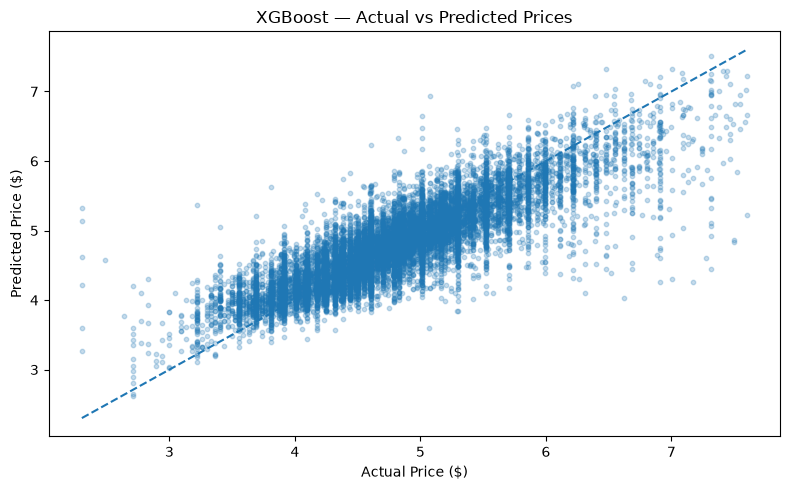

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    y_test,
    xgb_y_pred_test_log,
    alpha=0.25,
    s=10
)

min_price = min(y_test.min(), xgb_y_pred_test_log.min())
max_price = max(y_test.max(), xgb_y_pred_test_log.max())

ax.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

ax.set_xlabel("Actual Price ($)")
ax.set_ylabel("Predicted Price ($)")
ax.set_title("XGBoost — Actual vs Predicted Prices")

plt.tight_layout()
plt.show()

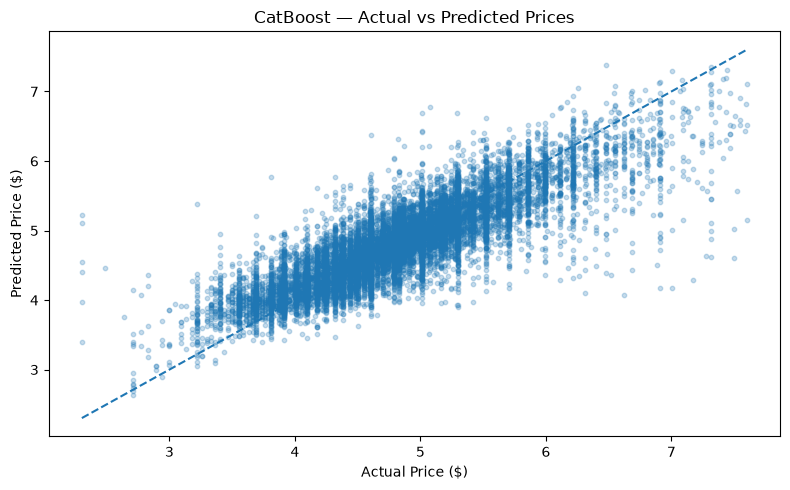

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    y_test,
    cat_y_pred_test_log,
    alpha=0.25,
    s=10
)

min_price = min(y_test.min(), cat_y_pred_test_log.min())
max_price = max(y_test.max(), cat_y_pred_test_log.max())

ax.plot(
    [min_price, max_price],
    [min_price, max_price],
    linestyle="--"
)

ax.set_xlabel("Actual Price ($)")
ax.set_ylabel("Predicted Price ($)")
ax.set_title("CatBoost — Actual vs Predicted Prices")

plt.tight_layout()
plt.show()

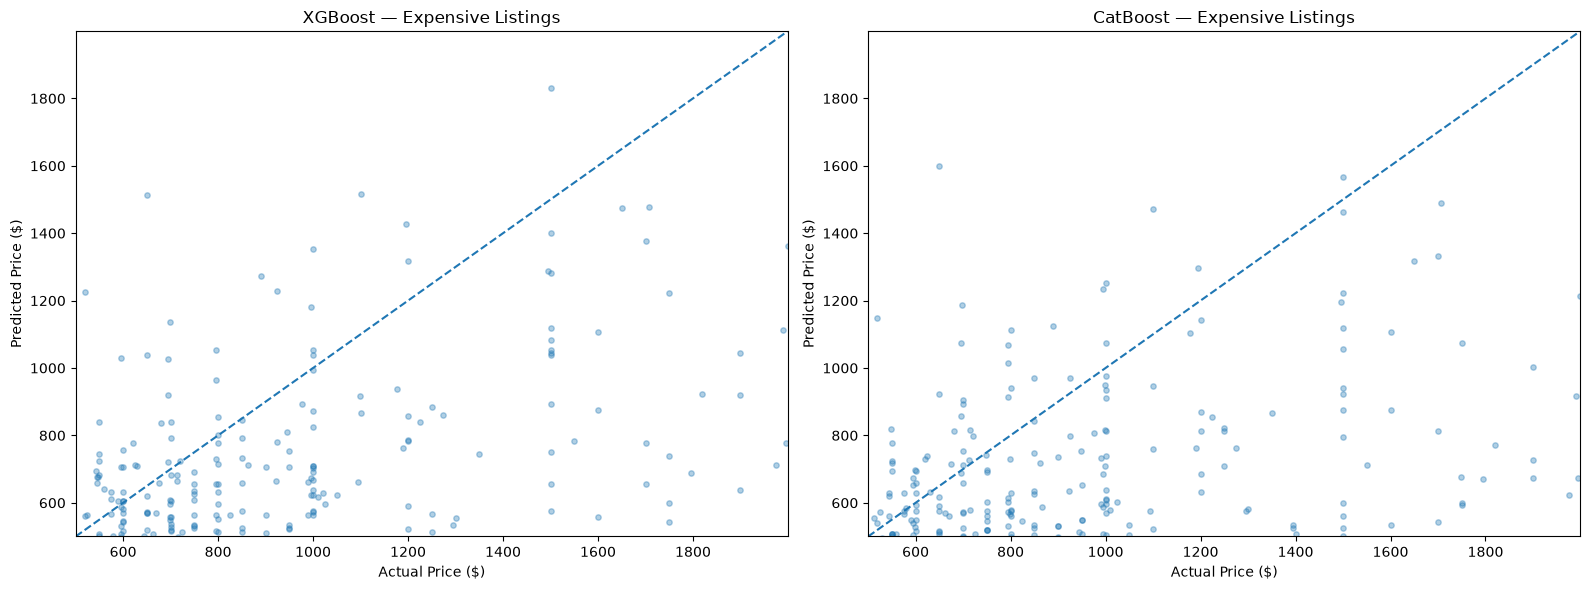

In [19]:
actual_price = np.exp(y_test)
xgb_price = np.exp(xgb_y_pred_test_log)
cat_price = np.exp(cat_y_pred_test_log)

price_threshold = 500
mask = actual_price >= price_threshold

max_price = max(
    actual_price[mask].max(),
    xgb_price[mask].max(),
    cat_price[mask].max()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(
    actual_price[mask],
    xgb_price[mask],
    alpha=0.35,
    s=15
)

axes[0].plot(
    [price_threshold, max_price],
    [price_threshold, max_price],
    linestyle="--"
)


axes[0].set_title("XGBoost — Expensive Listings")
axes[0].set_xlabel("Actual Price ($)")
axes[0].set_ylabel("Predicted Price ($)")
axes[0].set_xlim(price_threshold, max_price)
axes[0].set_ylim(price_threshold, max_price)

axes[1].scatter(
    actual_price[mask],
    cat_price[mask],
    alpha=0.35,
    s=15
)

axes[1].plot(
    [price_threshold, max_price],
    [price_threshold, max_price],
    linestyle="--"
)

axes[1].set_title("CatBoost — Expensive Listings")
axes[1].set_xlabel("Actual Price ($)")
axes[1].set_ylabel("Predicted Price ($)")
axes[1].set_xlim(price_threshold, max_price)
axes[1].set_ylim(price_threshold, max_price)

plt.tight_layout()
plt.show()

# Conclusion

After comparing the final XGBoost and CatBoost models, **XGboost was selected as the final model for this project**. 

XGBoost achieved slightly better performance on the test set, with a test MAE of **48.21**, Test RMSE of **110.88** and Test R2 score of **0.73**. 

Since the RMSE was the primary optimization metric throughout the project, the lower test RMSE makes XGBoost preferred model. This model will be used as the final model for the project and prepared for deployment in the next stage.